In [1]:
!pip install -q 'skorch[pytorch]' && pip install -q faiss-gpu-cu12

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 37.1 MB/s eta 0:00:00


In [2]:
## -- CHECK FOR 3RD PARTY LIBRARIES --
try:
    import pytabkit
    import skrub
except:
    %pip install pytabkit
    %pip install skrub

    import pytabkit
    import skrub

## -- PREREQUISITES FOR PyTabKit TREE MODELS (xgb_TD, lgbm_TD, cat_TD) --
try:
    import xgboost, lightgbm, catboost
except:
    %pip install xgboost lightgbm catboost
    import xgboost, lightgbm, catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 15.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 500.5/500.5 kB 19.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 4 cores


In [4]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
import tensorflow as tf

import sklearn
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibrationDisplay

import warnings

2026-02-27 21:41:22.516465: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772228482.785926      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772228482.864050      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772228483.508148      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772228483.508222      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772228483.508226      16 computation_placer.cc:177] computation placer alr

In [5]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
# plt.style.use("ggplot")
sns.set_style("whitegrid")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
SEED = 42
tf.keras.utils.set_random_seed(SEED)

GREEN  = '\033[32m'
YELLOW = '\033[33m'
RESET  = '\033[0m'

print(f"CLASSIC {GREEN} GREEN {RESET} {YELLOW} YELLOW {RESET}")

CLASSIC  GREEN   YELLOW 


In [6]:
## -- Load Data Kaggle --
PATH = '/kaggle/input/playground-series-s6e2/'
submit = pd.read_csv(PATH+'sample_submission.csv')
train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

ORIG_PATH = '/kaggle/input/datasets/sylvesterdalmeida/myheart-disease-dataset/'
orig = pd.read_csv(ORIG_PATH+'Heart_Disease_Prediction.csv')

## -- Remove trailing spaces in column names --
for col in test.columns:
    n = col.replace(' ', '_')
    print(f"Removing spaces in {col} to {n}")
    train.rename(columns={col: n}, inplace=True)
    test.rename(columns={col: n}, inplace=True)
    orig.rename(columns={col: n}, inplace=True)

TARGET = train.columns[-1]
NUMS   = ['Age', 'BP', 'Cholesterol', 'Max_HR', 'ST_depression']
CATS   = [c for c in train.columns if c not in [TARGET]+NUMS]

BASE = NUMS + CATS

for df in [train, orig]:
    df[TARGET] = df[TARGET].map({'Presence': 1, 'Absence': 0})

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Removing spaces in Age to Age
Removing spaces in Sex to Sex
Removing spaces in Chest pain type to Chest_pain_type
Removing spaces in BP to BP
Removing spaces in Cholesterol to Cholesterol
Removing spaces in FBS over 120 to FBS_over_120
Removing spaces in EKG results to EKG_results
Removing spaces in Max HR to Max_HR
Removing spaces in Exercise angina to Exercise_angina
Removing spaces in ST depression to ST_depression
Removing spaces in Slope of ST to Slope_of_ST
Removing spaces in Number of vessels fluro to Number_of_vessels_fluro
Removing spaces in Thallium to Thallium
Train shape: (630000, 14)
Test shape: (270000, 13)
Original shape: (270, 14)

Total Numerical: 5
Total Categorical: 8
Total base features: 13


In [7]:
# ## -- Load data Colab --
# from google.colab import drive
# drive.mount('/content/drive')

# PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e2 | Heart Disease/_heart_dataset/'

# submit = pd.read_csv(PATH+'sample_submission.csv')
# train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
# test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

# # ORIG_PATH = '/kaggle/input/heartdisease/'
# orig = pd.read_csv(PATH+'Heart_Disease_Prediction.csv')

# ## -- Remove trailing spaces in column names --
# for col in test.columns:
#     n = col.replace(' ', '_')
#     print(f"Removing spaces in {col} to {n}")
#     train.rename(columns={col: n}, inplace=True)
#     test.rename(columns={col: n}, inplace=True)
#     orig.rename(columns={col: n}, inplace=True)

# TARGET = train.columns[-1]
# NUMS   = ['Age', 'BP', 'Cholesterol', 'Max_HR', 'ST_depression']
# CATS   = [c for c in train.columns if c not in [TARGET]+NUMS]

# BASE = NUMS + CATS

# for df in [train, orig]:
#     df[TARGET] = df[TARGET].map({'Presence': 1, 'Absence': 0})

# for (name, df) in dict(Train=train, Test=test, Original=orig).items():
#     print(f"{name} shape: {df.shape}")

# print(f"\nTotal Numerical: {len(NUMS)}")
# print(f"Total Categorical: {len(CATS)}")
# print(f"Total base features: {len(BASE)}")

In [8]:
train.head(3)

,Age,Sex,Chest_pain_type,BP,Cholesterol,FBS_over_120,EKG_results,Max_HR,Exercise_angina,ST_depression,Slope_of_ST,Number_of_vessels_fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0


## FEATURE ENGINEERING

In [9]:
# ## -- Create 'meta' feature --
# ## -- https://www.kaggle.com/competitions/playground-series-s6e1/discussion/665915
# def meta_feature(df):
#     formula = (
#         6 * df.study_hours + \
#         0.35 * df.class_attendance + \
#         1.5 * df.sleep_hours + \
#         5 * (df.sleep_quality=='good') + \
#         -5 * (df.sleep_quality=='poor') + \
#         10 * (df.study_method=='coaching') + \
#         5 * (df.study_method=='mixed') + \
#         2 * (df.study_method=='group study') + \
#         1 * (df.study_method=='online videos') + \
#         4 * (df.facility_rating=='high') + \
#         -4 * (df.facility_rating=='low')
#     )
#     return formula

# train['formula'] = meta_feature(train)
# test['formula'] = meta_feature(test)
# orig['formula'] = meta_feature(orig)


In [10]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/CategoryMean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [11]:
def orig_TE_data_propagate(orig, X_train, X_val, X_test, features=None, aggs=None, fill_nan=False):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()

    ORIG = []
    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[TARGET].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[TARGET].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[TARGET].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[TARGET].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[TARGET].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[TARGET].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[TARGET].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            ## -- Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[TARGET].mean()
    global_median = orig[TARGET].median()

    def fill_conditionally(df):
        for c in ORIG:
            if c.endswith(('_mean', '_max', '_min')):
                df[c] = df[c].fillna(global_mean)
            elif c.endswith('_median'):
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [12]:
train, test, _, NEW_COLS = orig_TE_data_propagate(
    orig,
    train,
    test,
    train.sample(1000),
    features=NUMS,
    ## --- (count, mean, count, std, nunique, median, max, min)
    aggs=['mean'],
    fill_nan=True,
)

print(NEW_COLS)
train.isna().sum()

TE_merging:   0%|          | 0/5 [00:00<?, ?it/s]

['OTE_Age_mean', 'OTE_BP_mean', 'OTE_Cholesterol_mean', 'OTE_Max_HR_mean', 'OTE_ST_depression_mean']


Age                        0
Sex                        0
Chest_pain_type            0
BP                         0
Cholesterol                0
FBS_over_120               0
EKG_results                0
Max_HR                     0
Exercise_angina            0
ST_depression              0
Slope_of_ST                0
Number_of_vessels_fluro    0
Thallium                   0
Heart Disease              0
OTE_Age_mean               0
OTE_BP_mean                0
OTE_Cholesterol_mean       0
OTE_Max_HR_mean            0
OTE_ST_depression_mean     0
dtype: int64

In [13]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head(3)

Total Features: 18


,Age,Sex,Chest_pain_type,BP,Cholesterol,FBS_over_120,EKG_results,Max_HR,Exercise_angina,ST_depression,Slope_of_ST,Number_of_vessels_fluro,Thallium,Heart Disease,OTE_Age_mean,OTE_BP_mean,OTE_Cholesterol_mean,OTE_Max_HR_mean,OTE_ST_depression_mean
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1,0.666667,0.500000,0.5,0.50,1.000000
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0,0.272727,0.700000,0.0,0.25,0.258824
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0,0.666667,0.545455,1.0,0.00,0.258824


# ML TRAINING

In [14]:
from pytabkit import (
        RealMLP_TD_Classifier,
        TabM_D_Classifier,
        XGB_TD_Classifier,
        LGBM_TD_Classifier,
        CatBoost_TD_Classifier,
        Resnet_RTDL_D_Classifier,
        FTT_D_Classifier,
        MLP_RTDL_D_Classifier,
        MLP_PLR_D_Classifier,
        TabR_S_D_Classifier,
)

ML = len(
    [
        RealMLP_TD_Classifier,
        TabM_D_Classifier,
        XGB_TD_Classifier,
        LGBM_TD_Classifier,
        CatBoost_TD_Classifier,
        Resnet_RTDL_D_Classifier,
        FTT_D_Classifier,
        MLP_RTDL_D_Classifier,
        MLP_PLR_D_Classifier,
        TabR_S_D_Classifier,
    ]
)
print(f'⚙️ Models to train: {ML} ⚙️')

⚙️ Models to train: 10 ⚙️


In [15]:
def Trainer_CV(model_name, model_instance, train_df, test_df, features, target, kf, cats):
    print(f"\n==================== Starting Cross-Validation for {model_name} ====================")

    start = time()

    oof_preds = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))
    fold_scores = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(train_df[features], train_df[target])):
        print(f"\n- Fold {idx + 1}/{kf.n_splits} -", end='')

        # Split data for the current fold
        X_train, X_val = train_df.loc[train_idx, features], train_df.loc[val_idx, features]
        y_train, y_val = train_df.loc[train_idx, target], train_df.loc[val_idx, target]

        X_test = test_df[features].copy()

        # ## -- OPTION A: CONCATENATE ORIGINAL DATA --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)
        # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_val, X_test, NEW_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_val,
        #     X_test,
        #     features=NUMS,
        #     aggs=['mean'], # mean, count, std, skew, nunique, median, max, min
        #     fill_nan=True,
        # )

        cme_cats = NUMS 
        cme_cols = []
        print(f"CategoryMeanEncoding: {len(cme_cats)} | ", end='')
        for c in cme_cats:
            n = f"CME_{c}"
            CME = CategoryMeanTransformer(cat_cols=[c])
            X_train[n] = CME.fit_transform(X_train[[c]], y_train).fillna(-1)
            X_val[n]   = CME.transform(X_val[[c]]).fillna(-1)
            X_test[n]  = CME.transform(X_test[[c]]).fillna(-1)
            cme_cols.append(n)

        # ## -- TE Opt1. -> Using CUSTOM --
        # TE = TargetEncoder(NUMS, cv=5, smooth='auto', aggs=['mean'], drop_original=False)
        # X_train = TE.fit_transform(X_train, pd.Series(y_train))
        # X_val   = TE.transform(X_val)
        # X_test  = TE.transform(X_test)

        all_cats = cats
        combined = pd.concat([X_train, X_val, X_test])
        for c in all_cats:
            combined[c] = combined[c].astype(str).astype('category')

        X_train = combined.iloc[:len(X_train)]
        X_val   = combined.iloc[len(X_train):len(X_train)+len(X_val)]
        X_test  = combined.iloc[len(X_train)+len(X_val):]

        print(f"Train shape: {X_train.shape} ***")

        model_instance.fit(X_train, y_train, X_val, y_val , cat_col_names=all_cats)

        ## -- Predict on validation and test sets --
        oof_preds[val_idx] = model_instance.predict_proba(X_val)[:, 1].ravel()
        test_preds += model_instance.predict_proba(X_test)[:, 1].ravel()

        ## -- Calculate and print fold score --
        fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
        fold_scores.append(fold_auc)
        print(f'{YELLOW}\tFOLD {idx + 1} AUC: {fold_auc:.5f}{RESET}')

        ## -- Clean up memory --
        del X_train, X_val, y_train, y_val, X_test
        gc.collect()
        torch.cuda.empty_cache()

    ## -- Average the test predictions --
    test_preds /= kf.n_splits

    ## -- Print final cross-validation results --
    print("\n==================================================")
    print(f"Cross-Validation Results for {model_name}")
    print("==================================================")
    for i, score in enumerate(fold_scores):
        print(f"FOLD {i+1} AUC: {score:.5f}")

    ## -- Calculate final out-of-fold AUC --
    oof_auc = np.round(roc_auc_score(train_df[target], oof_preds), 6)

    print("-------------------------------------------------|")
    print(f"Overall AUC: {oof_auc}")
    print(f"Average AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_auc,
        'model': model_instance,
    }

print('⚙️⚙️ Training function ready ⚙️⚙️')

⚙️⚙️ Training function ready ⚙️⚙️


In [16]:
## === DEFINE GLOBAL PARAMETERS ==== ⬆️ v1_FE_realMLP_tabM
version_name = 'pytabV1gbts_'

EPOCHS   = 100
ETA      = 0.002

ALL_CATS = list(set(CATS))
all_model_predictions = {}
all_model_scores = {}

N_SPLITS = 15
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

kf

StratifiedKFold(n_splits=15, random_state=42, shuffle=True)

In [17]:
# ## ====================== REAL-MLP ======================
# # rmlp_param = {
# #         'device': 'cuda',
# #         'random_state': SEED,
# #         'verbosity': 2,
# #         'n_epochs': 100,
# #         'batch_size': 256,
# #         'n_ens': 8,
# #         'use_early_stopping': True,
# #         'early_stopping_additive_patience': 20,
# #         'early_stopping_multiplicative_patience': 1,
# #         'act': "mish",
# #         'embedding_size': 8,
# #         'first_layer_lr_factor': 0.5962121993798933,
# #         'hidden_sizes': "rectangular",
# #         'hidden_width': 384,
# #         'lr': 0.04,
# #         'ls_eps': 0.011498317194338772,
# #         'ls_eps_sched': "coslog4",
# #         'max_one_hot_cat_size': 18,
# #         'n_hidden_layers': 4,
# #         'p_drop': 0.07301419697186451,
# #         'p_drop_sched': "flat_cos",
# #         'plr_hidden_1': 16,
# #         'plr_hidden_2': 8,
# #         'plr_lr_factor': 0.1151437622270563,
# #         'plr_sigma': 2.3316811282666916,
# #         'scale_lr_factor': 2.244801835541429,
# #         'sq_mom': 1.0 - 0.011834054955582318,
# #         'wd': 0.02369230879235962,
# #     }

# py_model = RealMLP_TD_Classifier(**{
#     'act': 'selu',
#     'lr': 0.04,
#     'n_epochs': 100,
#     'act_lr_factor': 0.1,
#     'embedding_size': 8,
#     'batch_size': 256,
#     'hidden_sizes': [256, 512, 256],
#     'ls_eps': 0.01,
#     'p_drop': 0.1,
#     # 'plr_hidden_1': 16,
#     # 'plr_hidden_2': 8,
#     'plr_lr_factor': 0.1,
#     'plr_sigma': 0.1,
#     'scale_lr_factor': 2.5,
#     'use_early_stopping': True,
#     'early_stopping_additive_patience': 15, # def=20
#     'early_stopping_multiplicative_patience': 1, # def=2
#     'verbosity': 2,
#     'random_state': SEED,
#     'val_metric_name': '1-auc_ovr',
# })

# M_NAME = f'{version_name}realMLP'
# all_model_predictions[M_NAME] = Trainer_CV(
#     model_name=M_NAME,
#     model_instance=py_model,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=ALL_CATS,
# )

# ## -- Get models scores --
# for k, v in all_model_predictions.items():
#     for x, y in v.items():
#         if x == 'score':
#             # print(k, y)
#             all_model_scores[k] = y

# ## -- OOF PREDICTIONS --
# for i, (k, v) in enumerate(all_model_predictions.items()):
#     for x, y in v.items():
#         if x == 'oof_preds':
#             n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
#             file_oof = f"oof_{n}.npy"
#             np.save(file_oof, y)
# print('📥 OOF array saved!!')

# ## -- TEST PREDICTIONS --
# for i, (k, v) in enumerate(all_model_predictions.items()):
#     for x, y in v.items():
#         if x == 'test_preds':
#             n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
#             file_test = f"test_{n}.npy"
#             np.save(file_test, y)

# print('📥 TEST array saved!!')

In [18]:
# ## ====================== TAB-M =======================
# py_model = TabM_D_Classifier(**{
#     'arch_type': 'tabm-normal',
#     'num_emb_type': 'pwl',
#     # 'allow_amp': False,
#     'lr': 0.002,
#     'batch_size': 256,
#     # 'd_block': 512,
#     'n_epochs': 20,
#     'patience': 4,
#     'n_blocks': 3,
#     'tabm_k': 24,
#     'd_embedding': 16,
#     'dropout': 0.1,
#     # 'gradient_clipping_norm': None,
#     # 'num_emb_n_bins': 48,
#     'weight_decay': 0.01,
#     'random_state': SEED,
#     'verbosity': 2,
#     'val_metric_name': '1-auc_ovr',
# })

# M_NAME = f'{version_name}tabM'
# all_model_predictions[M_NAME] = Trainer_CV(
#     model_name=M_NAME,
#     model_instance=py_model,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=ALL_CATS,
# )

# ## -- Get models scores --
# for k, v in all_model_predictions.items():
#     for x, y in v.items():
#         if x == 'score':
#             # print(k, y)
#             all_model_scores[k] = y

# ## -- Get oof predictions --
# for i, (k, v) in enumerate(all_model_predictions.items()):
#     for x, y in v.items():
#         if x == 'oof_preds':
#             n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
#             file_oof = f"oof_{n}.npy"
#             np.save(file_oof, y)

# print('📥 OOF array saved!!')

# ## -- Get test predictions --
# for i, (k, v) in enumerate(all_model_predictions.items()):
#     for x, y in v.items():
#         if x == 'test_preds':
#             n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
#             file_test = f"test_{n}.npy"
#             np.save(file_test, y)

# print('📥 TEST array saved!!')

In [19]:
## ====================== XGBOOST =======================
py_model = XGB_TD_Classifier(**{
    'n_estimators': 20_000,
    'max_depth': 2,
    'lr': 0.03,
    'subsample': 0.9,
    'colsample_bytree': 0.4,
    'reg_lambda': 2.5,
    'alpha': 3.5,
    # 'min_child_weight': 5.0,
    # 'max_cat_to_onehot': 9,
    'verbosity': 0,
    'random_state': SEED,
    'val_metric_name': '1-auc_ovr',
})

M_NAME = f'{version_name}xgb'
all_model_predictions[M_NAME] = Trainer_CV(
    model_name=M_NAME,
    model_instance=py_model,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=ALL_CATS,
)

## ====================== LIGHTGBM =======================
py_model = LGBM_TD_Classifier(**{
    'n_estimators': 20_000,
    'max_depth': 4,
    # 'num_leaves': 8,
    'lr': 0.03,
    'subsample': 0.8,
    'colsample_bytree': 0.2,
    'lambda_l1': 2.5,
    'lambda_l2': 0.2,
    'min_data_in_leaf': 20,
    # 'min_sum_hessian_in_leaf': 1e-3,
    'verbosity': -1,
    'random_state': SEED,
    'val_metric_name': '1-auc_ovr',
})

M_NAME = f'{version_name}lgb'
all_model_predictions[M_NAME] = Trainer_CV(
    model_name=M_NAME,
    model_instance=py_model,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=ALL_CATS,
)

## ====================== CATBOOST =======================
py_model = CatBoost_TD_Classifier(**{
    'boosting_type': 'Plain', # 'Ordered'
    'bootstrap_type': 'Bayesian',
    'n_estimators': 20_000,
    'max_depth': 6,
    'lr': 0.03,
    'l2_leaf_reg': 3.0,
    # 'subsample': 0.8,
    # 'one_hot_max_size': 9,
    # 'random_strength': 0.8,
    'verbosity': 0,
    'random_state': SEED,
    'val_metric_name': '1-auc_ovr',
})

M_NAME = f'{version_name}cat'
for booster in ['Plain', 'Ordered']:
    py_model.boosting_type = booster
    all_model_predictions[M_NAME] = Trainer_CV(
        model_name=M_NAME+'_'+booster,
        model_instance=py_model,
        train_df=train,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kf=kf,
        cats=ALL_CATS,
    )


## -- Get models scores --
for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            # print(k, y)
            all_model_scores[k] = y

## -- OOF PREDICTIONS --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            file_oof = f"oof_{n}.npy"
            np.save(file_oof, y)
print('📥 OOF array saved!!')

## -- TEST PREDICTIONS --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'test_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            file_test = f"test_{n}.npy"
            np.save(file_test, y)

print('📥 TEST array saved!!')


==================== Starting Cross-Validation for pytabV1gbts_xgb ====================

- Fold 1/15 -CategoryMeanEncoding: 5 | Train shape: (588000, 23) ***
	FOLD 1 AUC: 0.95621

- Fold 2/15 -CategoryMeanEncoding: 5 | Train shape: (588000, 23) ***
	FOLD 2 AUC: 0.95619

- Fold 3/15 -CategoryMeanEncoding: 5 | Train shape: (588000, 23) ***
	FOLD 3 AUC: 0.95596

- Fold 4/15 -CategoryMeanEncoding: 5 | Train shape: (588000, 23) ***
	FOLD 4 AUC: 0.95565

- Fold 5/15 -CategoryMeanEncoding: 5 | Train shape: (588000, 23) ***
	FOLD 5 AUC: 0.95438

- Fold 6/15 -CategoryMeanEncoding: 5 | Train shape: (588000, 23) ***
	FOLD 6 AUC: 0.95484

- Fold 7/15 -CategoryMeanEncoding: 5 | Train shape: (588000, 23) ***
	FOLD 7 AUC: 0.95597

- Fold 8/15 -CategoryMeanEncoding: 5 | Train shape: (588000, 23) ***
	FOLD 8 AUC: 0.95619

- Fold 9/15 -CategoryMeanEncoding: 5 | Train shape: (588000, 23) ***
	FOLD 9 AUC: 0.95537

- Fold 10/15 -CategoryMeanEncoding: 5 | Train shape: (588000, 23) ***
	FOLD 10 AUC: 0.95508

In [20]:
# ==================================================
# Cross-Validation Results for pytabV1_xgb
# ==================================================
# FOLD 1 AUC: 0.95606
# FOLD 2 AUC: 0.95487
# FOLD 3 AUC: 0.95577
# FOLD 4 AUC: 0.95538
# FOLD 5 AUC: 0.95616
# -------------------------------------------------|
# Overall AUC: 0.955648
# Average AUC: 0.955649 ± 0.000474
# -------------------------------------------------|
# 15.38 mins

# ==================================================
# Cross-Validation Results for pytabV1_lgb
# ==================================================
# FOLD 1 AUC: 0.95597
# FOLD 2 AUC: 0.95479
# FOLD 3 AUC: 0.95570
# FOLD 4 AUC: 0.95531
# FOLD 5 AUC: 0.95616
# -------------------------------------------------|
# Overall AUC: 0.955582
# Average AUC: 0.955588 ± 0.000493
# -------------------------------------------------|
# 9.40 mins

# ==================================================
# Cross-Validation Results for pytabV1_cat_Plain
# ==================================================
# FOLD 1 AUC: 0.95600
# FOLD 2 AUC: 0.95483
# FOLD 3 AUC: 0.95569
# FOLD 4 AUC: 0.95530
# FOLD 5 AUC: 0.95611
# -------------------------------------------------|
# Overall AUC: 0.955583
# Average AUC: 0.955585 ± 0.000471
# -------------------------------------------------|
# 8.46 mins

In [21]:
# ## ====================== MLP-PLR =======================
# py_model = MLP_PLR_D_Classifier(**{
#     'batch_size': 128,
#     'max_epochs': 100,
#     'es_patience': 5,
#     'lr': 0.002,
#     # 'lr_patience': 5,
#     # 'lr_scheduler': False,
#     # 'module_d_embedding': 8,
#     # 'module_d_first_layer': 128,
#     # 'module_d_last_layer': 128,
#     # 'module_d_layers': [128, 256, 128],
#     # 'module_n_layers': 3,
#     # 'module_dropout': 0.1,
#     # 'module_num_emb_dim': 24,
#     # 'module_num_emb_hidden_dim': 48,
#     'n_threads': os.cpu_count(),
#     'verbose': 2,
#     'random_state': SEED,
#     'val_metric_name': '1-auc_ovr',
# })

# M_NAME = f'{version_name}mlpPLR'
# all_model_predictions[M_NAME] = Trainer_CV(
#     model_name=M_NAME,
#     model_instance=py_model,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=ALL_CATS,
# )

# ## -- Get models scores --
# for k, v in all_model_predictions.items():
#     for x, y in v.items():
#         if x == 'score':
#             # print(k, y)
#             all_model_scores[k] = y

# ## -- Get oof predictions --
# for i, (k, v) in enumerate(all_model_predictions.items()):
#     for x, y in v.items():
#         if x == 'oof_preds':
#             n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
#             file_oof = f"oof_{n}.npy"
#             np.save(file_oof, y)
# print('📥 OOF array saved!!')

# ## -- Get test predictions --
# for i, (k, v) in enumerate(all_model_predictions.items()):
#     for x, y in v.items():
#         if x == 'test_preds':
#             n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
#             file_test = f"test_{n}.npy"
#             np.save(file_test, y)

# print('📥 TEST array saved!!')

In [22]:
# ## ====================== MLP-RTDL ======================
# py_model = MLP_RTDL_D_Classifier(**{
#     'batch_size': 128,
#     'max_epochs': 100,
#     'es_patience': 5,
#     'lr': 0.002,
#     # 'lr_patience': 30,
#     # 'lr_scheduler': False,
#     # 'module_d_embedding': 8,
#     # 'module_d_first_layer': 128,
#     # 'module_d_last_layer': 128,
#     # 'module_d_layers': [128, 256, 128],
#     # 'module_n_layers': 3,
#     # 'module_dropout': 0.1,
#     'verbose': 2,
#     'random_state': SEED,
# })

# M_NAME = f'{version_name}mlpRTDL'
# all_model_predictions[m_name] = Trainer_CV(
#     model_name=m_name,
#     model_instance=py_model,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=ALL_CATS,
# )

# ## -- Get models scores --
# for k, v in all_model_predictions.items():
#     for x, y in v.items():
#         if x == 'score':
#             # print(k, y)
#             all_model_scores[k] = y

# ## -- Get oof predictions --
# for i, (k, v) in enumerate(all_model_predictions.items()):
#     for x, y in v.items():
#         if x == 'oof_preds':
#             n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
#             file_oof = f"oof_{n}.npy"
#             np.save(file_oof, y)
# print('📥 OOF array saved!!')

# ## -- Get test predictions --
# for i, (k, v) in enumerate(all_model_predictions.items()):
#     for x, y in v.items():
#         if x == 'test_preds':
#             n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
#             file_test = f"test_{n}.npy"
#             np.save(file_test, y)

# print('📥 TEST array saved!!')

In [23]:
# ## ====================== RESNET-RTDL ======================
# py_model = Resnet_RTDL_D_Classifier(**{
#     'batch_size': 128,
#     'max_epochs': 100,
#     'es_patience': 5,
#     'lr': 0.002,
#     # 'lr_patience': 30,
#     # 'lr_scheduler': False,
#     # 'module_d': 128,
#     # 'module_d_embedding': 8,
#     # 'module_d_hidden_factor': 2,
#     # 'module_hidden_dropout': 0.25,
#     # 'module_n_layers': 2,
#     # 'module_residual_dropout': 0.1,
#     # 'optimizer_weight_decay': 0.01,
#     'verbose': 2,
#     'random_state': SEED,
# })

# M_NAME = f'{version_name}resNetRTDL'
# all_model_predictions[m_name] = Trainer_CV(
#     model_name=m_name,
#     model_instance=py_model,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=ALL_CATS,
# )

# ## -- Get models scores --
# for k, v in all_model_predictions.items():
#     for x, y in v.items():
#         if x == 'score':
#             # print(k, y)
#             all_model_scores[k] = y

# ## -- Get oof predictions --
# for i, (k, v) in enumerate(all_model_predictions.items()):
#     for x, y in v.items():
#         if x == 'oof_preds':
#             n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
#             file_oof = f"oof_{n}.npy"
#             np.save(file_oof, y)
# print('📥 OOF array saved!!')

# ## -- Get test predictions --
# for i, (k, v) in enumerate(all_model_predictions.items()):
#     for x, y in v.items():
#         if x == 'test_preds':
#             n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
#             file_test = f"test_{n}.npy"
#             np.save(file_test, y)

# print('📥 TEST array saved!!')

In [24]:
# ## ====================== TAB-R =======================
# py_model = TabR_S_D_Classifier(**{
#     # 'batch_size': 256*4,
#     'n_epochs': 5, # EPOCHS,
#     # 'context_size': 96, #
#     # 'd_main': 265,
#     # 'd_multiplier': 2.0,
#     # 'context_dropout': 0.38920071545944357,
#     # 'dropout0': 0.38852797479169876,
#     # 'dropout1': 0.0,
#     # 'encoder_n_blocks': 0,
#     # 'freeze_contexts_after_n_epochs': None,
#     # 'num_embeddings': None,
#     # 'predictor_n_blocks': 1,
#     'optimizer': {
#         'lr': ETA, #
#         'type': 'AdamW', 'weight_decay': 1.2260352006404615e-06},
#     'patience': 3,
#     'verbosity': 2,
#     'random_state': SEED,
#     # 'val_metric_name': 'auc',
# })

# M_NAME = f'{version_name}tabR'
# all_model_predictions[m_name] = Trainer_CV(
#     model_name=m_name,
#     model_instance=py_model,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=ALL_CATS,
# )

# ## -- Get models scores --
# for k, v in all_model_predictions.items():
#     for x, y in v.items():
#         if x == 'score':
#             # print(k, y)
#             all_model_scores[k] = y

# ## -- Get oof predictions --
# for i, (k, v) in enumerate(all_model_predictions.items()):
#     for x, y in v.items():
#         if x == 'oof_preds':
#             n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
#             file_oof = f"oof_{n}.npy"
#             np.save(file_oof, y)
# print('📥 OOF array saved!!')

# ## -- Get test predictions --
# for i, (k, v) in enumerate(all_model_predictions.items()):
#     for x, y in v.items():
#         if x == 'test_preds':
#             n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
#             file_test = f"test_{n}.npy"
#             np.save(file_test, y)

# print('📥 TEST array saved!!')

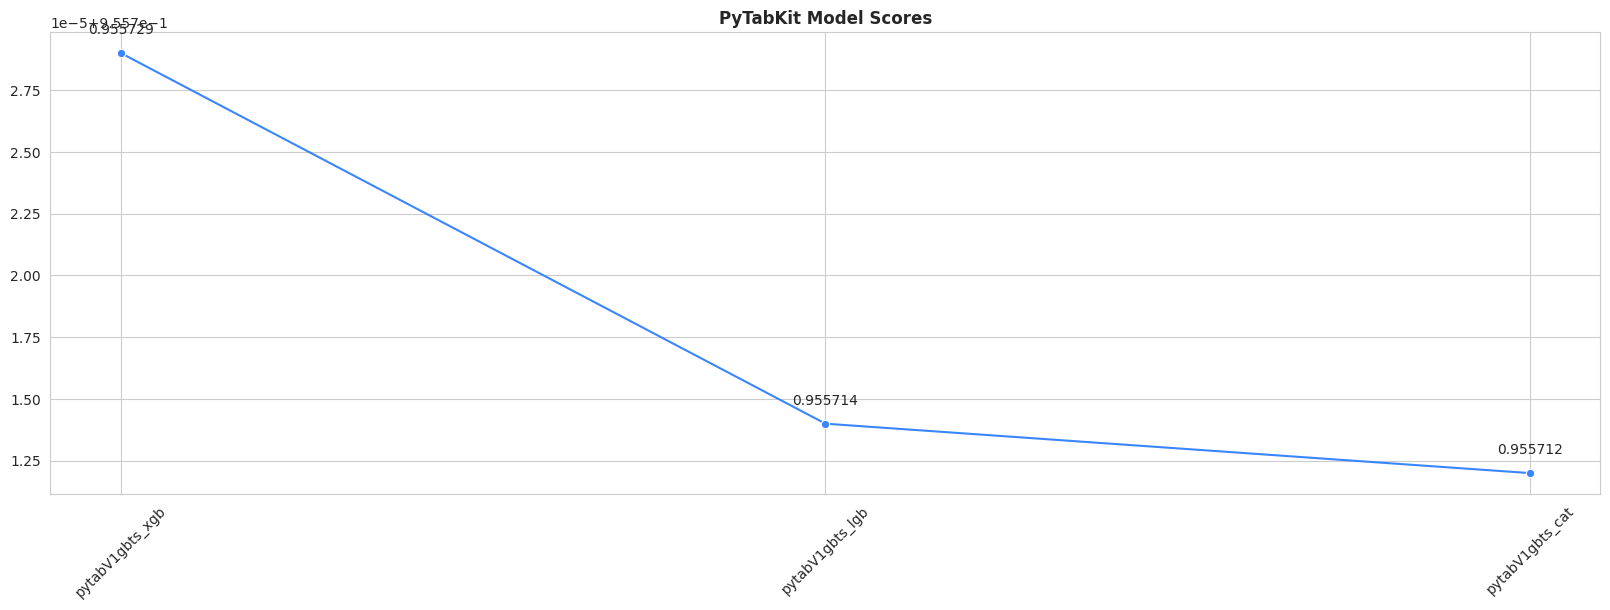

In [25]:
## -- Get models scores --
all_model_scores = {}

for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            # print(k, y)
            all_model_scores[k] = y

plt.figure(figsize=(20, 6))
sns.lineplot(all_model_scores, marker='o')
# pd.Series(all_model_scores).plot(marker='o')
for i, score in enumerate(all_model_scores.values()):
    plt.text(float(i), score+1e-6, score, ha='center', va='center_baseline')

plt.title('PyTabKit Model Scores', fontweight='semibold')
plt.tick_params('x', rotation=45)
plt.show()

In [26]:
## -- Get oof predictions --
all_model_oof = pd.DataFrame()

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            all_model_oof = pd.concat([all_model_oof, pd.DataFrame({n: y})], axis=1)

all_model_oof.to_parquet(f"oof_{version_name}.parquet", index=False)

all_model_oof.head()

,pytabV1gbts_xgb_955729,pytabV1gbts_lgb_955714,pytabV1gbts_cat_955712
0,0.998164,0.997165,0.996317
1,0.009052,0.009863,0.011573
2,0.008742,0.010285,0.012284
3,0.049908,0.048909,0.047653
4,0.997827,0.997516,0.996348


In [27]:
## -- Get test predictions --
all_model_test = pd.DataFrame()

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'test_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            all_model_test = pd.concat([all_model_test, pd.DataFrame({n: y})], axis=1)

all_model_test.to_parquet(f"test_{version_name}.parquet", index=False)

all_model_test.head()

,pytabV1gbts_xgb_955729,pytabV1gbts_lgb_955714,pytabV1gbts_cat_955712
0,0.948050,0.950061,0.957897
1,0.008034,0.008406,0.010548
2,0.992389,0.991010,0.988336
3,0.003916,0.004534,0.006707
4,0.198799,0.187720,0.182252


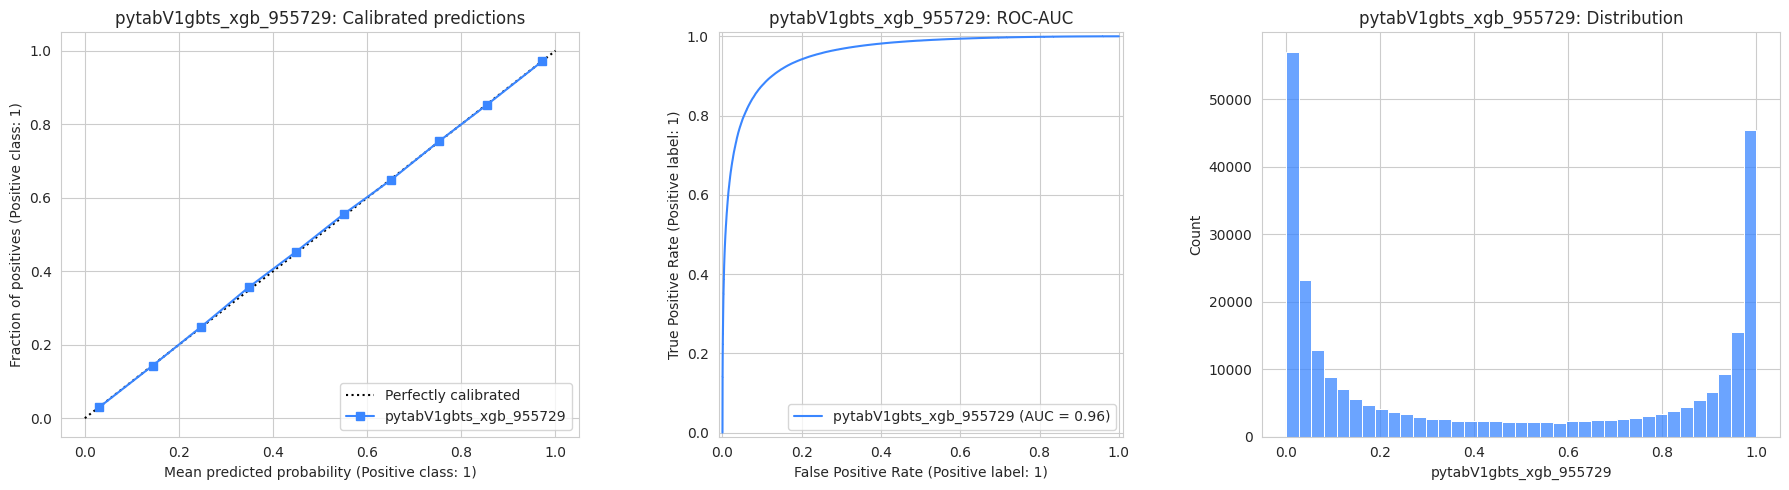

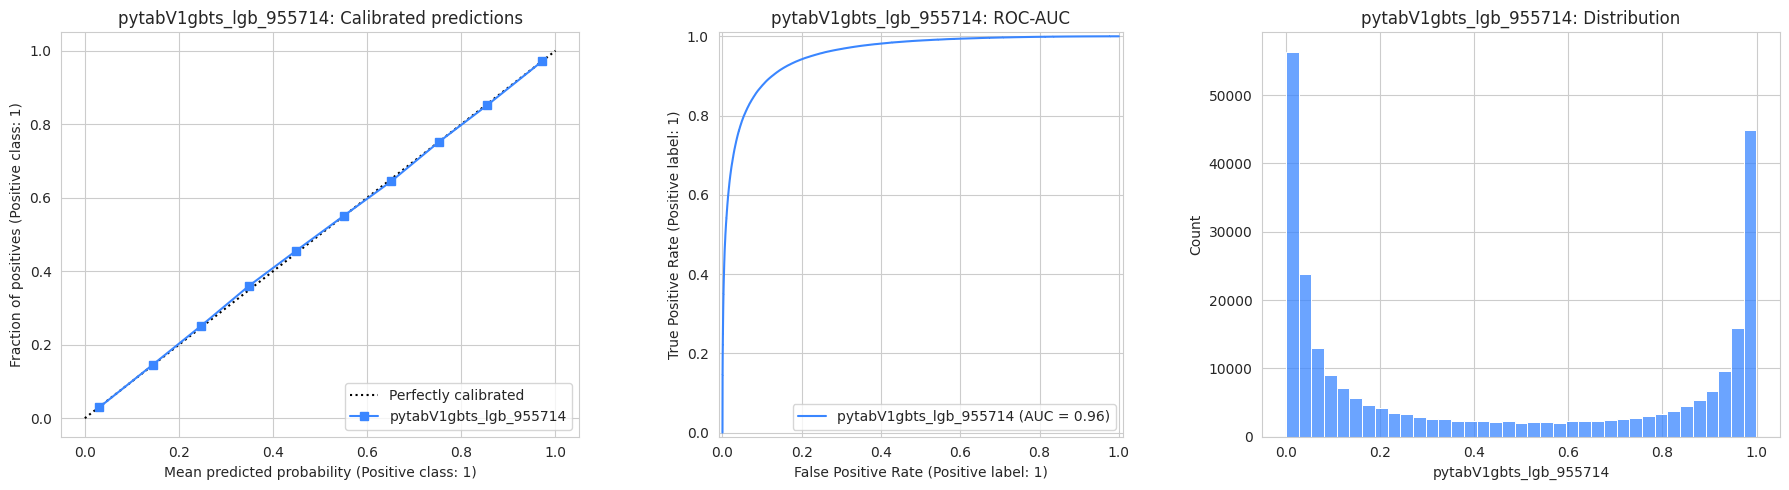

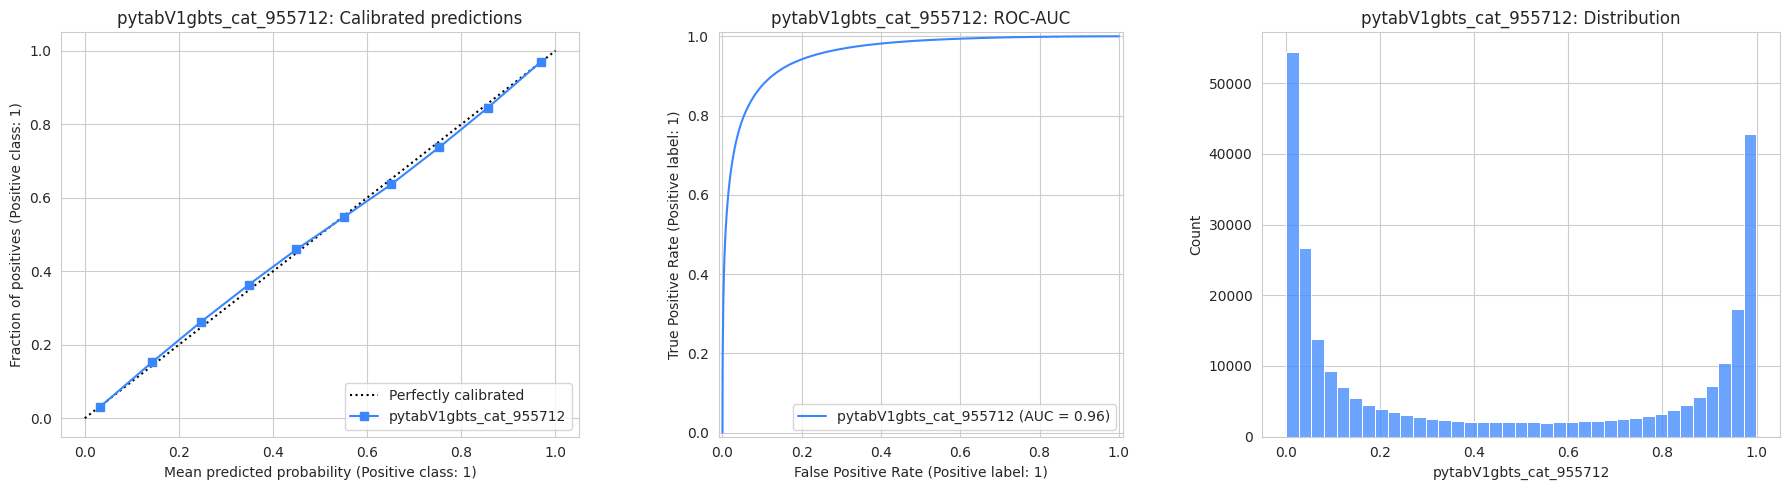

In [28]:
## -- PLOT PREDICTIONS --
for i, n in enumerate(all_model_test.columns):
    _, axs = plt.subplots(1, 3, figsize=(18, 5))

    CalibrationDisplay.from_predictions(train[TARGET], all_model_oof[n], n_bins=10, name=n, ax=axs[0])
    axs[0].set_title(f"{n}: Calibrated predictions")

    RocCurveDisplay.from_predictions(train[TARGET], all_model_oof[n], name=n, ax=axs[1])
    axs[1].set_title(f"{n}: ROC-AUC")
    # axs[1].grid(False)

    sns.histplot(all_model_test[n], ax=axs[2])
    axs[2].set_title(f"{n}: Distribution")

    plt.tight_layout()
    plt.show()
    print()